# `ml4t.backtest.risk` Module Demo
**Docker image**: `ml4t`

**Chapter 19: Quantitative Risk Management**

## Purpose
Walk through the `ml4t.backtest.risk` library — the production implementation of
the risk-management concepts in this chapter — across position-level exit rules,
rule composition, and portfolio-level kill switches.

## Learning Objectives
After completing this notebook, you will be able to:
- Configure position-level exit rules (`StopLoss`, `TrailingStop`, `TakeProfit`)
- Compose multiple rules with priority and boolean logic (`RuleChain`, `AllOf`, `AnyOf`)
- Set up portfolio-wide risk limits (`MaxDrawdownLimit`, `DailyLossLimit`)
- Identify which rule triggered and why from each evaluation result

## Book reference
Sections 19.4 (drawdowns and recovery), 19.7 (adaptive controls), 19.8 (kill switches and governance).

## Prerequisites
- Comfort with the backtest framework introduced in Chapter 17
- Section 19.4 (`02_exit_strategies.ipynb`) and Section 19.4 (`03_position_sizing_mae_mfe.ipynb`) for the rules' analytical motivation

In [1]:
"""ml4t.backtest.risk Module Demo — configure and test position-level exit rules and portfolio-wide risk limits."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest.risk import (
    AllOf,
    AnyOf,
    DailyLossLimit,
    GrossExposureLimit,
    # Portfolio limits
    MaxDrawdownLimit,
    MaxPositionsLimit,
    NetExposureLimit,
    PortfolioState,
    # Types
    PositionState,
    # Rule composition
    RuleChain,
    ScaledExit,
    # Position rules
    StopLoss,
    TakeProfit,
    TighteningTrailingStop,
    TimeExit,
    TrailingStop,
)
from plotly.subplots import make_subplots

import utils  # noqa: F401  # adds repo root to sys.path so `from ml4t...` resolves
from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
N_BARS = 252
N_ASSETS = 3
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Position-Level Exit Rules

The `ml4t.backtest.risk.position` module provides exit rules that operate on
individual positions. Each rule evaluates a `PositionState` and returns a
`PositionAction` (HOLD, EXIT_FULL, EXIT_PARTIAL, or ADJUST_STOP).

### 1.1 Creating Position States

First, let's create helper functions to simulate position evolution.

In [4]:
def create_position_state(
    asset: str = "SPY",
    side: str = "long",
    entry_price: float = 100.0,
    current_price: float = 100.0,
    bars_held: int = 0,
    quantity: int = 100,
    bar_high: float | None = None,
    bar_low: float | None = None,
) -> PositionState:
    """Create a PositionState for rule evaluation."""
    # Calculate derived values
    if side == "long":
        unrealized_return = (current_price / entry_price) - 1
        unrealized_pnl = (current_price - entry_price) * quantity
    else:
        unrealized_return = (entry_price / current_price) - 1
        unrealized_pnl = (entry_price - current_price) * quantity

    return PositionState(
        asset=asset,
        side=side,
        entry_price=entry_price,
        current_price=current_price,
        bar_high=bar_high if bar_high else current_price,
        bar_low=bar_low if bar_low else current_price,
        quantity=quantity,
        initial_quantity=quantity,
        unrealized_pnl=unrealized_pnl,
        unrealized_return=unrealized_return,
        bars_held=bars_held,
        high_water_mark=max(entry_price, current_price),
        low_water_mark=min(entry_price, current_price),
        max_favorable_excursion=max(0, unrealized_return),
        max_adverse_excursion=min(0, unrealized_return),
    )

### 1.2 Static Exit Rules

Static rules have fixed thresholds that don't change during the position lifetime.

In [5]:
stop_loss = StopLoss(pct=0.05)
take_profit = TakeProfit(pct=0.10)
time_exit = TimeExit(max_bars=20)

**`StopLoss(pct=0.05)`** — exit at 5% drawdown from entry.

In [6]:
scenarios = [
    ("Entry price", 100.0, 100.0),
    ("Down 3%", 100.0, 97.0),
    ("Down 5% (trigger)", 100.0, 95.0),
    ("Down 7%", 100.0, 93.0),
]

for name, entry, current in scenarios:
    state = create_position_state(entry_price=entry, current_price=current)
    action = stop_loss.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  {name}: entry=${entry}, current=${current} -> {status}")
    if action.reason:
        print(f"    Reason: {action.reason}")

  Entry price: entry=$100.0, current=$100.0 -> hold
  Down 3%: entry=$100.0, current=$97.0 -> hold
  Down 5% (trigger): entry=$100.0, current=$95.0 -> TRIGGERED
    Reason: stop_loss_5.0%
  Down 7%: entry=$100.0, current=$93.0 -> TRIGGERED
    Reason: stop_loss_5.0%


**`TakeProfit(pct=0.10)`** — exit at 10% gain from entry.

In [7]:
scenarios = [
    ("Entry price", 100.0, 100.0),
    ("Up 5%", 100.0, 105.0),
    ("Up 10% (trigger)", 100.0, 110.0),
    ("Up 15%", 100.0, 115.0),
]

for name, entry, current in scenarios:
    state = create_position_state(entry_price=entry, current_price=current)
    action = take_profit.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  {name}: entry=${entry}, current=${current} -> {status}")

  Entry price: entry=$100.0, current=$100.0 -> hold
  Up 5%: entry=$100.0, current=$105.0 -> hold
  Up 10% (trigger): entry=$100.0, current=$110.0 -> hold
  Up 15%: entry=$100.0, current=$115.0 -> TRIGGERED


**`TimeExit(max_bars=20)`** — exit after 20 bars regardless of P&L.

In [8]:
for bars in [5, 15, 19, 20, 25]:
    state = create_position_state(bars_held=bars)
    action = time_exit.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  Bars held: {bars} -> {status}")

  Bars held: 5 -> hold
  Bars held: 15 -> hold
  Bars held: 19 -> hold
  Bars held: 20 -> TRIGGERED
  Bars held: 25 -> TRIGGERED


### 1.3 Dynamic Exit Rules

Dynamic rules have thresholds that adapt to position performance.

**`TrailingStop(pct=0.05)`** — exit when price retraces 5% from the running high.
Simulated path: entry $100 → rises to $120 → falls back.

In [9]:
trailing_stop = TrailingStop(pct=0.05)

states = [
    create_position_state(entry_price=100, current_price=100),
    create_position_state(entry_price=100, current_price=110),
    create_position_state(entry_price=100, current_price=120),  # New high
    create_position_state(entry_price=100, current_price=116),  # Down 3.3%
    create_position_state(entry_price=100, current_price=114),  # Down 5% (trigger)
]

# Update high water marks properly
hwm = 100.0
for i, state in enumerate(states):
    hwm = max(hwm, state.current_price)
    state.high_water_mark = hwm
    action = trailing_stop.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    trail_level = hwm * 0.95
    print(f"  Price ${state.current_price}: HWM=${hwm}, trail=${trail_level:.1f} -> {status}")

  Price $100: HWM=$100.0, trail=$95.0 -> hold
  Price $110: HWM=$110, trail=$104.5 -> hold
  Price $120: HWM=$120, trail=$114.0 -> hold
  Price $116: HWM=$120, trail=$114.0 -> hold
  Price $114: HWM=$120, trail=$114.0 -> TRIGGERED


**`TighteningTrailingStop`** — trail width shrinks as the position becomes more
profitable. Schedule: 5% trail at 0%+, 3% trail at 10%+, 2% trail at 20%+ return.

In [10]:
tightening = TighteningTrailingStop(
    [
        (0.00, 0.05),
        (0.10, 0.03),
        (0.20, 0.02),
    ]
)

# Simulate profitable position
for return_pct in [0.05, 0.12, 0.22]:
    current_price = 100 * (1 + return_pct)
    state = create_position_state(entry_price=100, current_price=current_price)
    state.unrealized_return = return_pct
    state.high_water_mark = current_price  # At peak
    trail_pct = tightening._get_trail_pct(return_pct)
    print(f"  At {return_pct:.0%} return: trail tightens to {trail_pct:.0%}")

  At 5% return: trail tightens to 5%
  At 12% return: trail tightens to 3%
  At 22% return: trail tightens to 2%


**`ScaledExit`** — partial exits at profit targets. Schedule: +5% → exit 25%,
+10% → exit 33% of remaining, +15% → exit 50% of remaining.

In [11]:
scaled = ScaledExit(
    [
        (0.05, 0.25),
        (0.10, 0.33),
        (0.15, 0.50),
    ]
)

# Simulate rising position
for return_pct in [0.03, 0.05, 0.08, 0.10, 0.15]:
    state = create_position_state(entry_price=100, current_price=100 * (1 + return_pct))
    state.unrealized_return = return_pct
    action = scaled.evaluate(state)
    if action.action.name == "EXIT_PARTIAL":
        print(f"  At {return_pct:.0%}: EXIT {action.pct:.0%} of position ({action.reason})")
    else:
        print(f"  At {return_pct:.0%}: hold")

  At 3%: hold
  At 5%: EXIT 25% of position (scale_out_5%_25%)
  At 8%: hold
  At 10%: EXIT 33% of position (scale_out_10%_33%)
  At 15%: EXIT 50% of position (scale_out_15%_50%)


## 2. Rule Composition

The `ml4t.backtest.risk` module provides composition patterns to combine rules:

- **RuleChain**: First non-HOLD wins (priority order)
- **AllOf**: All must trigger (AND logic)
- **AnyOf**: Any can trigger (OR logic, alias for RuleChain)

**`RuleChain`** — first non-`HOLD` rule wins. Priority order:
`StopLoss(5%)` > `TakeProfit(10%)` > `TrailingStop(3%)` > `TimeExit(20)`.

In [12]:
chain = RuleChain(
    [
        StopLoss(pct=0.05),
        TakeProfit(pct=0.10),
        TrailingStop(pct=0.03),
        TimeExit(max_bars=20),
    ]
)

# Test scenarios
test_cases = [
    ("Loss triggers stop", 100, 94, 5, 100),  # Stop loss
    ("Profit triggers TP", 100, 112, 5, 112),  # Take profit
    ("Trail triggers", 100, 108, 5, 115),  # Fell from 115 to 108 (>3%)
    ("Time triggers", 100, 102, 22, 105),  # Held 22 bars
    ("Nothing triggers", 100, 102, 5, 102),  # All hold
]

for name, entry, current, bars, hwm in test_cases:
    state = create_position_state(entry_price=entry, current_price=current, bars_held=bars)
    state.high_water_mark = hwm
    action = chain.evaluate(state)
    if action.action.name != "HOLD":
        print(f"  {name}: {action.reason}")
    else:
        print(f"  {name}: HOLD")

  Loss triggers stop: stop_loss_5.0%
  Profit triggers TP: take_profit_10.0%
  Trail triggers: trailing_stop_3.0%
  Time triggers: time_exit_20bars
  Nothing triggers: HOLD


**`AllOf`** — AND logic; every constituent rule must trigger. Example: exit
only if profitable (`TakeProfit(0%)`) AND held at least 5 bars (`TimeExit(5)`).

In [13]:
all_of = AllOf(
    [
        TakeProfit(pct=0.0),
        TimeExit(max_bars=5),
    ]
)

test_cases = [
    ("Profitable, 3 bars", 0.05, 3),
    ("Profitable, 5 bars", 0.05, 5),
    ("Loss, 10 bars", -0.02, 10),
    ("Breakeven, 5 bars", 0.0, 5),
]

for name, ret, bars in test_cases:
    state = create_position_state(entry_price=100, current_price=100 * (1 + ret), bars_held=bars)
    state.unrealized_return = ret
    action = all_of.evaluate(state)
    status = "EXIT" if action.action.name != "HOLD" else "HOLD"
    print(f"  {name} (ret={ret:.0%}, bars={bars}): {status}")

  Profitable, 3 bars (ret=5%, bars=3): HOLD
  Profitable, 5 bars (ret=5%, bars=5): EXIT
  Loss, 10 bars (ret=-2%, bars=10): HOLD
  Breakeven, 5 bars (ret=0%, bars=5): EXIT


**`AnyOf`** — OR logic; first triggering rule wins. Semantically equivalent
to `RuleChain` for non-partial actions: `StopLoss(5%)` OR `TakeProfit(10%)`
OR `TimeExit(20)`.

In [14]:
any_of = AnyOf(
    [
        StopLoss(pct=0.05),
        TakeProfit(pct=0.10),
        TimeExit(max_bars=20),
    ]
)
{
    "AnyOf type": type(any_of).__name__,
    "rules in chain": len(any_of.rules),
    "doc": (AnyOf.__doc__ or "").strip().splitlines()[0] if AnyOf.__doc__ else "",
}

{'AnyOf type': 'AnyOf',
 'rules in chain': 3,
 'doc': 'First rule to return non-HOLD wins (alias for RuleChain).'}

## 3. Portfolio-Level Limits

Portfolio limits operate on the entire portfolio state, not individual positions.
They implement **kill switches** and **guardrails** discussed in Section 19.8.

`create_portfolio_state` packages the inputs (equity, high-water mark,
positions, daily P&L) into a `PortfolioState` so each limit check has a
single object to reason about. We use it as a scaffold in the demos
below; in production the backtester reconstructs `PortfolioState` from
the broker on every bar.

In [15]:
def create_portfolio_state(
    equity: float = 100000,
    initial_equity: float = 100000,
    high_water_mark: float = 100000,
    num_positions: int = 5,
    positions: dict | None = None,
    daily_pnl: float = 0,
) -> PortfolioState:
    """Create a PortfolioState for limit checks."""
    if positions is None:
        positions = {f"ASSET_{i}": equity / 10 for i in range(num_positions)}

    gross = sum(abs(v) for v in positions.values())
    net = sum(positions.values())

    drawdown = 0 if equity >= high_water_mark else (high_water_mark - equity) / high_water_mark

    return PortfolioState(
        equity=equity,
        initial_equity=initial_equity,
        high_water_mark=high_water_mark,
        current_drawdown=drawdown,
        num_positions=num_positions,
        positions=positions,
        daily_pnl=daily_pnl,
        gross_exposure=gross,
        net_exposure=net,
    )

**`MaxDrawdownLimit`** — halt at 20% drawdown, warn at 15%.

In [16]:
dd_limit = MaxDrawdownLimit(max_drawdown=0.20, warn_threshold=0.15)

for dd_pct in [0.05, 0.10, 0.15, 0.18, 0.20, 0.25]:
    equity = 100000 * (1 - dd_pct)
    state = create_portfolio_state(equity=equity, high_water_mark=100000)
    result = dd_limit.check(state)
    if result.breached:
        print(f"  Drawdown {dd_pct:.0%}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  Drawdown {dd_pct:.0%}: OK")

  Drawdown 5%: OK
  Drawdown 10%: OK
  Drawdown 15%: WARN - drawdown 15.0% >= warn threshold 15.0%
  Drawdown 18%: WARN - drawdown 18.0% >= warn threshold 15.0%
  Drawdown 20%: LIQUIDATE - drawdown 20.0% >= 20.0%
  Drawdown 25%: LIQUIDATE - drawdown 25.0% >= 20.0%


**`DailyLossLimit`** — halt if today's P&L exceeds a 2% loss.

In [17]:
daily_limit = DailyLossLimit(max_daily_loss_pct=0.02)

for daily_pnl in [500, 0, -1000, -2000, -2500]:
    state = create_portfolio_state(equity=100000, daily_pnl=daily_pnl)
    result = daily_limit.check(state)
    pct = daily_pnl / 100000 * 100
    if result.breached:
        print(f"  Daily P&L ${daily_pnl:+,} ({pct:+.1f}%): {result.action.upper()}")
    else:
        print(f"  Daily P&L ${daily_pnl:+,} ({pct:+.1f}%): OK")

  Daily P&L $+500 (+0.5%): OK
  Daily P&L $+0 (+0.0%): OK
  Daily P&L $-1,000 (-1.0%): OK
  Daily P&L $-2,000 (-2.0%): OK
  Daily P&L $-2,500 (-2.5%): LIQUIDATE


**`MaxPositionsLimit`** — cap concurrent positions at 10.

In [18]:
pos_limit = MaxPositionsLimit(max_positions=10)

for n_pos in [5, 8, 10, 12]:
    positions = {f"ASSET_{i}": 10000 for i in range(n_pos)}
    state = create_portfolio_state(num_positions=n_pos, positions=positions)
    result = pos_limit.check(state)
    if result.breached:
        print(f"  {n_pos} positions: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {n_pos} positions: OK")

  5 positions: OK
  8 positions: OK
  10 positions: HALT - positions 10 >= max 10
  12 positions: HALT - positions 12 >= max 10


**`GrossExposureLimit`** — cap gross exposure (= leverage) at 150% of equity.

In [19]:
gross_limit = GrossExposureLimit(max_gross_exposure=1.5)

for leverage in [0.8, 1.0, 1.3, 1.5, 2.0]:
    positions = {"LONG": 100000 * leverage / 2, "SHORT": -100000 * leverage / 2}
    state = create_portfolio_state(
        equity=100000,
        positions=positions,
        num_positions=2,
    )
    result = gross_limit.check(state)
    if result.breached:
        print(f"  {leverage:.0%} gross: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {leverage:.0%} gross: OK")

  80% gross: OK
  100% gross: OK
  130% gross: OK
  150% gross: OK
  200% gross: HALT - gross exposure 200.0% > max 150.0%


**`NetExposureLimit`** — enforce market neutrality within ±10% net exposure.

In [20]:
net_limit = NetExposureLimit(max_net_exposure=0.10, min_net_exposure=-0.10)

test_cases = [
    ("Neutral", {"LONG": 50000, "SHORT": -50000}),
    ("+5% net", {"LONG": 55000, "SHORT": -50000}),
    ("+15% net", {"LONG": 60000, "SHORT": -45000}),
    ("-12% net", {"LONG": 44000, "SHORT": -56000}),
]

for name, positions in test_cases:
    state = create_portfolio_state(equity=100000, positions=positions, num_positions=2)
    result = net_limit.check(state)
    if result.breached:
        print(f"  {name}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {name}: OK")

  Neutral: OK
  +5% net: OK
  +15% net: WARN - net exposure 15.0% > max 10.0%
  -12% net: WARN - net exposure -12.0% < min -10.0%


## 4. Practical Example: Complete Risk Framework

Combining position rules and portfolio limits into a coherent framework.

In [21]:
# Define position-level rules
position_rules = RuleChain(
    [
        StopLoss(pct=0.03),  # 3% hard stop
        TighteningTrailingStop(
            [
                (0.00, 0.05),  # 5% trail initially
                (0.10, 0.03),  # Tighten to 3% at +10%
                (0.20, 0.02),  # Tighten to 2% at +20%
            ]
        ),
        TakeProfit(pct=0.30),  # 30% take profit
        TimeExit(max_bars=60),  # Exit after 60 bars
    ]
)

# Define portfolio-level limits
portfolio_limits = [
    MaxDrawdownLimit(max_drawdown=0.15, warn_threshold=0.10),
    DailyLossLimit(max_daily_loss_pct=0.02),
    MaxPositionsLimit(max_positions=20),
    GrossExposureLimit(max_gross_exposure=1.0),
]

**Position Rules (RuleChain, in priority order)**:

1. `StopLoss(3%)` — hard stop on entry-price drawdown
2. `TighteningTrailingStop(5% → 3% → 2%)` — trail tightens with profit
3. `TakeProfit(30%)` — final target
4. `TimeExit(60 bars)` — maximum holding period

**Portfolio Limits**:

1. `MaxDrawdownLimit(15%)` — halt at 15% drawdown, warn at 10%
2. `DailyLossLimit(2%)` — halt at 2% intraday drawdown
3. `MaxPositionsLimit(20)` — cap concurrent positions
4. `GrossExposureLimit(100%)` — no leverage

### Simulate a Trading Day

In [22]:
# Simulate 3 positions with different outcomes
positions_sim = [
    {
        "symbol": "AAPL",
        "entry_price": 150.0,
        "prices": [150, 148, 146, 145.5, 145],  # Declining -> stop loss
        "bars": 5,
    },
    {
        "symbol": "GOOGL",
        "entry_price": 100.0,
        "prices": [100, 108, 115, 118, 116],  # Rise then trail triggers
        "bars": 5,
    },
    {
        "symbol": "MSFT",
        "entry_price": 300.0,
        "prices": [300, 305, 310, 308, 312],  # Steady rise, hold
        "bars": 5,
    },
]

In [23]:
# Evaluate position rules across simulated price paths
for pos in positions_sim:
    print(f"\n{pos['symbol']} (entry: ${pos['entry_price']})")

    hwm = pos["entry_price"]
    for i, price in enumerate(pos["prices"]):
        hwm = max(hwm, price)
        state = create_position_state(
            asset=pos["symbol"],
            entry_price=pos["entry_price"],
            current_price=price,
            bars_held=i,
        )
        state.high_water_mark = hwm

        action = position_rules.evaluate(state)
        ret = (price / pos["entry_price"] - 1) * 100

        if action.action.name != "HOLD":
            print(f"  Bar {i}: ${price} ({ret:+.1f}%) HWM=${hwm:.0f} -> EXIT: {action.reason}")
            break
        else:
            print(f"  Bar {i}: ${price} ({ret:+.1f}%) HWM=${hwm:.0f} -> hold")


AAPL (entry: $150.0)
  Bar 0: $150 (+0.0%) HWM=$150 -> hold
  Bar 1: $148 (-1.3%) HWM=$150 -> hold
  Bar 2: $146 (-2.7%) HWM=$150 -> hold
  Bar 3: $145.5 (-3.0%) HWM=$150 -> EXIT: stop_loss_3.0%

GOOGL (entry: $100.0)
  Bar 0: $100 (+0.0%) HWM=$100 -> hold
  Bar 1: $108 (+8.0%) HWM=$108 -> hold
  Bar 2: $115 (+15.0%) HWM=$115 -> hold
  Bar 3: $118 (+18.0%) HWM=$118 -> hold
  Bar 4: $116 (+16.0%) HWM=$118 -> hold

MSFT (entry: $300.0)
  Bar 0: $300 (+0.0%) HWM=$300 -> hold
  Bar 1: $305 (+1.7%) HWM=$305 -> hold
  Bar 2: $310 (+3.3%) HWM=$310 -> hold
  Bar 3: $308 (+2.7%) HWM=$310 -> hold
  Bar 4: $312 (+4.0%) HWM=$312 -> hold


### Portfolio Limit Check

In [24]:
# Simulate portfolio state after a tough day
portfolio = create_portfolio_state(
    equity=92000,  # Down from 100k
    initial_equity=100000,
    high_water_mark=105000,  # Was up 5% at peak
    daily_pnl=-1800,  # Down $1,800 today
    num_positions=8,
    positions={f"POS_{i}": 11500 for i in range(8)},  # 92% gross exposure
)

print("\nPortfolio State:")
print(f"  Equity: ${portfolio.equity:,.0f}")
print(f"  High Water Mark: ${portfolio.high_water_mark:,.0f}")
print(f"  Current Drawdown: {portfolio.current_drawdown:.1%}")
print(f"  Daily P&L: ${portfolio.daily_pnl:+,.0f} ({portfolio.daily_pnl / portfolio.equity:.1%})")
print(f"  Positions: {portfolio.num_positions}")
print(f"  Gross Exposure: {portfolio.gross_exposure / portfolio.equity:.0%}")

print("\nLimit Checks:")
for limit in portfolio_limits:
    result = limit.check(portfolio)
    limit_name = limit.__class__.__name__
    if result.breached:
        print(f"  {limit_name}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {limit_name}: OK")


Portfolio State:
  Equity: $92,000
  High Water Mark: $105,000
  Current Drawdown: 12.4%
  Daily P&L: $-1,800 (-2.0%)
  Positions: 8
  Gross Exposure: 100%

Limit Checks:
  MaxDrawdownLimit: WARN - drawdown 12.4% >= warn threshold 10.0%
  DailyLossLimit: OK
  MaxPositionsLimit: OK
  GrossExposureLimit: OK


## 5. Visualizations

Three views that show when and how risk rules act.

### 5a. Position State Timeline

When do different rules trigger across the price path?

In [25]:
# Real SPY 2020 — covers the COVID drawdown so SL, TrailingStop, and TakeProfit
# all fire on the same path.
_spy = load_etfs(symbols=["SPY"], start_date="2020-01-01", end_date="2020-12-31").sort("timestamp")
prices = _spy["close"].to_numpy()[:N_BARS]

# Evaluate rules at each bar
rules = {
    "StopLoss(5%)": StopLoss(pct=0.05),
    "TrailingStop(3%)": TrailingStop(pct=0.03),
    "TakeProfit(15%)": TakeProfit(pct=0.15),
}

trigger_bars = {}
for rule_name, rule in rules.items():
    hwm = prices[0]
    for i, p in enumerate(prices):
        hwm = max(hwm, p)
        state = create_position_state(
            entry_price=prices[0],
            current_price=p,
            bars_held=i,
        )
        state.high_water_mark = hwm
        action = rule.evaluate(state)
        if action.action.name != "HOLD":
            trigger_bars[rule_name] = i
            break

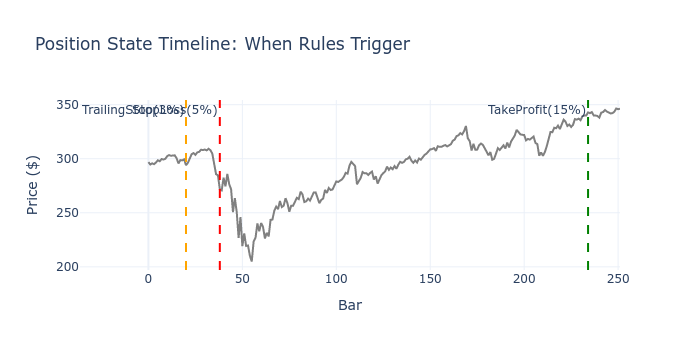

In [26]:
# Visualize rule trigger points on the price path
fig = go.Figure()
fig.add_trace(go.Scatter(y=prices.tolist(), name="Price", line=dict(color="gray")))
colors = {"StopLoss(5%)": "red", "TrailingStop(3%)": "orange", "TakeProfit(15%)": "green"}
for rule_name, bar_idx in trigger_bars.items():
    fig.add_vline(
        x=bar_idx,
        line_dash="dash",
        line_color=colors.get(rule_name, "blue"),
        annotation_text=rule_name,
        annotation_position="top left",
    )
fig.update_layout(
    title="Position State Timeline: When Rules Trigger",
    xaxis_title="Bar",
    yaxis_title="Price ($)",
    height=350,
    template="plotly_white",
)
fig.show()

### 5b. Return Distribution: Managed vs Unmanaged

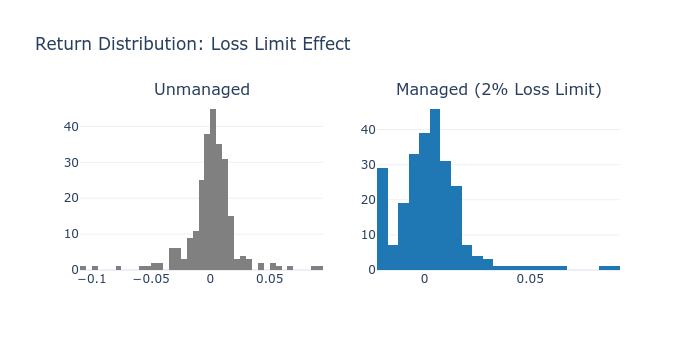

In [27]:
# Real SPY 2020 daily returns — the loss-limit demo bites into the COVID
# left tail rather than an artificial Gaussian sample.
raw_returns = np.diff(prices) / prices[:-1]
managed_returns = np.clip(raw_returns, -0.02, None)  # 2% daily loss limit

fig = make_subplots(rows=1, cols=2, subplot_titles=["Unmanaged", "Managed (2% Loss Limit)"])
fig.add_trace(
    go.Histogram(x=raw_returns.tolist(), nbinsx=50, marker_color="gray", name="Unmanaged"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(x=managed_returns.tolist(), nbinsx=50, marker_color="#1f77b4", name="Managed"),
    row=1,
    col=2,
)
fig.update_layout(
    height=350,
    title="Return Distribution: Loss Limit Effect",
    showlegend=False,
    template="plotly_white",
)
fig.show()

The managed distribution shows a hard wall at -2%, truncating left-tail
losses. This improves skewness (less negative) and reduces kurtosis
(thinner left tail).

### 5c. Multi-Rule Comparison

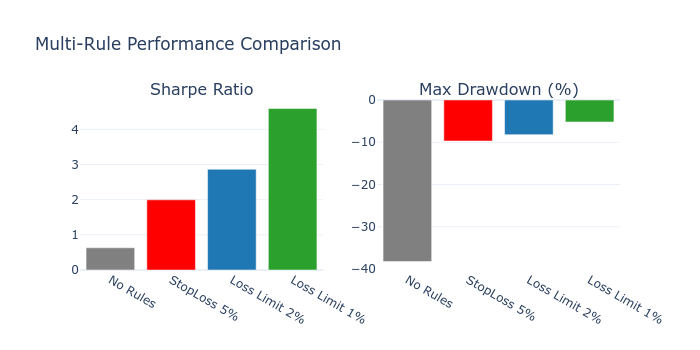

In [28]:
configs = {
    "No Rules": raw_returns,
    "StopLoss 5%": np.where(
        np.cumsum(raw_returns) / (1 + np.cumsum(raw_returns)) < -0.05, 0.0, raw_returns
    ),
    "Loss Limit 2%": np.clip(raw_returns, -0.02, None),
    "Loss Limit 1%": np.clip(raw_returns, -0.01, None),
}

metrics = []
for name, rets in configs.items():
    sharpe = float(np.mean(rets) / np.std(rets) * np.sqrt(252)) if np.std(rets) > 0 else 0
    max_dd = float(np.min(np.cumsum(rets) - np.maximum.accumulate(np.cumsum(rets))))
    metrics.append(
        {"config": name, "sharpe": round(sharpe, 3), "max_dd_pct": round(max_dd * 100, 1)}
    )

fig = make_subplots(rows=1, cols=2, subplot_titles=["Sharpe Ratio", "Max Drawdown (%)"])
fig.add_trace(
    go.Bar(
        x=[m["config"] for m in metrics],
        y=[m["sharpe"] for m in metrics],
        marker_color=["gray", "red", "#1f77b4", "#2ca02c"],
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=[m["config"] for m in metrics],
        y=[m["max_dd_pct"] for m in metrics],
        marker_color=["gray", "red", "#1f77b4", "#2ca02c"],
    ),
    row=1,
    col=2,
)
fig.update_layout(
    height=350, title="Multi-Rule Performance Comparison", showlegend=False, template="plotly_white"
)
fig.show()

## 6. Key Statistics for Book Prose

Summary of library capabilities demonstrated.

In [29]:
library_coverage = pl.DataFrame(
    [
        {
            "category": "Position rule types",
            "count": 6,
            "examples": "StopLoss, TakeProfit, TimeExit, TrailingStop, TighteningTrailingStop, ScaledExit",
        },
        {
            "category": "Composition patterns",
            "count": 3,
            "examples": "RuleChain, AllOf, AnyOf",
        },
        {
            "category": "Portfolio limit types",
            "count": 5,
            "examples": "MaxDrawdownLimit, DailyLossLimit, MaxPositionsLimit, GrossExposureLimit, NetExposureLimit",
        },
    ]
)
library_coverage

category,count,examples
str,i64,str
"""Position rule types""",6,"""StopLoss, TakeProfit, TimeExit…"
"""Composition patterns""",3,"""RuleChain, AllOf, AnyOf"""
"""Portfolio limit types""",5,"""MaxDrawdownLimit, DailyLossLim…"


**Section integration**:

- §19.4 references `StopLoss`, `TrailingStop`, `TighteningTrailingStop` for drawdown / recovery management.
- §19.7 references `RuleChain` for adaptive controls.
- §19.8 references `MaxDrawdownLimit`, `DailyLossLimit` for kill switches.

## Key Takeaways

1. **Position rules and portfolio limits live in different layers.**
   The six position rules (`StopLoss`, `TakeProfit`, `TimeExit`,
   `TrailingStop`, `TighteningTrailingStop`, `ScaledExit`) decide
   *individual* exits; the five portfolio limits
   (`MaxDrawdownLimit`, `DailyLossLimit`, `MaxPositionsLimit`,
   `GrossExposureLimit`, `NetExposureLimit`) decide *system-wide*
   halts. The two are not interchangeable.
2. **Composition expresses ordering, conjunction, and disjunction
   cleanly.** `RuleChain` picks the first non-`None` action;
   `AllOf` requires every rule to agree; `AnyOf` fires if any rule
   triggers. Most production exit logic is a one-line composition of
   these three primitives.
3. **Portfolio limits are governance, not parameters.** Sweep
   position-level rules across grids (`11_systematic_risk_sweep`); fix
   portfolio limits from the risk mandate. The threshold for
   `MaxDrawdownLimit` is a policy decision, not a hyperparameter.

Implementation reference: `ml4t.backtest.risk` module API; case-study
usage in the nine `strategy/risk_management.py` notebooks.

**Next**: [`11_systematic_risk_sweep`](11_systematic_risk_sweep.ipynb)
applies these position rules to 1D and 2D grids and shows how the
resulting surfaces interact with MAE/MFE-calibrated cuts.